# Лабораторна робота № 2

## Оптимізаційна задача та аналіз чутливості

**Дисципліна:** Інтелектуальний аналіз та візуалізація даних (СК26)
**Тривалість:** 2 год аудиторно + 3 год самостійної роботи · **Максимальна оцінка:** 4 бали

---

### Мета роботи

Побудувати оптимізаційну модель у двох середовищах, прочитати звіт про стійкість
і **ухвалити на його основі господарське рішення**.

Розв'язати задачу — не мета. Solver зробить це за дві секунди. Робота оцінюється за
те, що ви зумієте зі звіту витягнути.

### Дві частини

| Частина | Задача | Де виконується |
|---|---|---|
| **1** | виробнича задача — Excel і Python | аудиторно |
| **2** | транспортна задача — Python | самостійно |

Друга частина потрібна не для повторення. Там та сама методика поводиться інакше,
і ви маєте побачити, де саме проходить межа її застосовності.

### Що здається

1. Цей файл `.ipynb` із заповненими розв'язками. **Виконується згори донизу на чистому
   ядрі** (Kernel → Restart & Run All) без помилок — перевіряється першою дією на захисті.
2. Файл Excel з моделлю, налаштуваннями Solver і **звітом про стійкість** окремим аркушем.
3. Заповнена декларація про використання ШІ (етап 12).

### Оцінювання

| Бали | Що досягнуто |
|---|---|
| 0 | Модель не сформульовано або розв'язок не отримано |
| 1 | Розв'язок отримано лише в одному середовищі, звіт про стійкість не проаналізовано |
| 2 | Задачу розв'язано в обох середовищах і звіти зіставлено, але тіньові ціни та діапазони не інтерпретовано |
| 4 | Звіт прочитано й перевірено експериментом, ухвалено обґрунтоване рішення про закупівлю, виконано частину 2 з поясненням розбіжності |

---
## Крок 0. Ваші дані та варіант

In [2]:
ПІБ = 'Ляшко Леся'        # напр. 'Шевченко Тарас'
ГРУПА = 'ШІ-32'      # напр. 'КН-31'
ВАРІАНТ = 9     # ваш номер за списком групи

assert ПІБ and ГРУПА and 1 <= ВАРІАНТ <= 30, 'Заповніть ПІБ, ГРУПУ та ВАРІАНТ (1..30)'

In [3]:
# --- клітинку не редагувати: вона видає дані вашого варіанта -----------------
import json, numpy as np, pandas as pd

ДАНІ_ВАРІАНТІВ = json.loads('''{"1": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[0, 2, 1, 1], [3, 3, 0, 6], [2, 3, 0, 2], [4, 6, 0, 5], [3, 1, 5, 4]], "c": [21, 69, 44, 39], "b": [929, 410, 507, 865, 425], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.2, "обсяг_пропозиції": 44}, "2": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 2, 5, 2], [6, 5, 4, 2], [5, 2, 0, 3], [2, 1, 5, 0], [5, 5, 6, 2]], "c": [40, 66, 24, 34], "b": [1271, 702, 915, 1388, 804], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.7, "обсяг_пропозиції": 204}, "3": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 2, 6, 6], [3, 4, 3, 6], [1, 6, 6, 0], [3, 1, 6, 1], [4, 1, 1, 4]], "c": [51, 16, 34, 22], "b": [1189, 686, 1311, 512, 1030], "ресурс_пропозиції": 3, "ціна_пропозиції": 11.3, "обсяг_пропозиції": 348}, "4": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 0, 0, 0], [1, 0, 5, 2], [2, 4, 6, 5], [3, 0, 5, 3], [2, 1, 2, 5]], "c": [41, 50, 54, 26], "b": [815, 344, 840, 840, 382], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.3, "обсяг_пропозиції": 144}, "5": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 0, 6, 6], [3, 2, 2, 4], [5, 5, 0, 6], [2, 1, 5, 3], [5, 5, 4, 2]], "c": [32, 66, 25, 24], "b": [874, 1034, 1349, 845, 1394], "ресурс_пропозиції": 2, "ціна_пропозиції": 8.6, "обсяг_пропозиції": 90}, "6": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[3, 2, 1, 4], [4, 2, 2, 1], [3, 5, 1, 2], [3, 2, 0, 2], [6, 4, 6, 3]], "c": [40, 62, 19, 57], "b": [630, 391, 1349, 811, 1085], "ресурс_пропозиції": 1, "ціна_пропозиції": 29.5, "обсяг_пропозиції": 268}, "7": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[0, 0, 5, 5], [4, 4, 0, 1], [2, 4, 0, 6], [6, 3, 4, 1], [2, 2, 1, 0]], "c": [20, 59, 63, 41], "b": [1189, 1189, 1217, 915, 424], "ресурс_пропозиції": 3, "ціна_пропозиції": 8.0, "обсяг_пропозиції": 314}, "8": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[2, 1, 3, 5], [3, 1, 0, 6], [1, 6, 1, 5], [2, 2, 4, 0], [6, 1, 2, 2]], "c": [60, 25, 59, 25], "b": [1279, 761, 376, 1230, 1065], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.5, "обсяг_пропозиції": 234}, "9": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 2, 1, 2], [5, 0, 1, 3], [5, 4, 6, 4], [4, 1, 1, 5], [6, 0, 3, 0]], "c": [58, 39, 54, 16], "b": [1147, 1199, 1280, 404, 1170], "ресурс_пропозиції": 2, "ціна_пропозиції": 6.1, "обсяг_пропозиції": 672}, "10": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 0, 4, 3], [0, 6, 0, 6], [5, 5, 3, 5], [6, 2, 3, 3], [3, 0, 0, 4]], "c": [20, 29, 37, 63], "b": [905, 344, 866, 1390, 355], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.3, "обсяг_пропозиції": 78}, "11": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 3], [3, 1, 4, 0], [1, 0, 3, 2], [3, 2, 2, 6], [3, 6, 0, 3]], "c": [30, 16, 51, 35], "b": [1312, 838, 1062, 1038, 1236], "ресурс_пропозиції": 1, "ціна_пропозиції": 15.6, "обсяг_пропозиції": 778}, "12": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 2, 0, 5], [1, 1, 3, 6], [6, 3, 5, 4], [2, 4, 6, 0], [4, 6, 2, 4]], "c": [39, 55, 36, 26], "b": [788, 661, 458, 1005, 535], "ресурс_пропозиції": 4, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 762}, "13": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[1, 5, 3, 0], [6, 4, 6, 3], [4, 4, 4, 1], [0, 3, 5, 3], [3, 5, 3, 3]], "c": [59, 42, 53, 19], "b": [937, 1390, 603, 1120, 1334], "ресурс_пропозиції": 2, "ціна_пропозиції": 15.1, "обсяг_пропозиції": 646}, "14": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 3, 3, 4], [6, 6, 1, 6], [1, 3, 5, 1], [1, 5, 1, 4], [4, 4, 0, 3]], "c": [26, 56, 41, 40], "b": [969, 672, 1364, 878, 618], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.0, "обсяг_пропозиції": 222}, "15": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[5, 3, 3, 1], [2, 5, 6, 6], [3, 1, 0, 0], [0, 4, 4, 6], [2, 2, 2, 6]], "c": [64, 58, 34, 63], "b": [613, 316, 1035, 739, 810], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.4, "обсяг_пропозиції": 354}, "16": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[1, 6, 4, 2], [4, 1, 1, 2], [4, 4, 6, 6], [5, 6, 3, 3], [1, 2, 4, 2]], "c": [33, 40, 58, 17], "b": [412, 1005, 996, 599, 390], "ресурс_пропозиції": 4, "ціна_пропозиції": 8.2, "обсяг_пропозиції": 44}, "17": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[2, 6, 0, 3], [2, 5, 5, 3], [6, 0, 4, 5], [1, 3, 6, 2], [0, 1, 4, 4]], "c": [33, 52, 20, 66], "b": [989, 1079, 873, 1327, 1224], "ресурс_пропозиції": 0, "ціна_пропозиції": 5.9, "обсяг_пропозиції": 402}, "18": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 3, 0, 1], [0, 6, 1, 6], [1, 0, 4, 1], [2, 6, 3, 4], [3, 1, 6, 5]], "c": [66, 54, 18, 66], "b": [1217, 668, 923, 1040, 619], "ресурс_пропозиції": 4, "ціна_пропозиції": 34.9, "обсяг_пропозиції": 100}, "19": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 0, 2], [3, 3, 4, 5], [2, 1, 0, 4], [4, 1, 5, 0], [0, 3, 6, 3]], "c": [67, 52, 41, 40], "b": [315, 617, 815, 423, 1193], "ресурс_пропозиції": 1, "ціна_пропозиції": 9.3, "обсяг_пропозиції": 332}, "20": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[5, 4, 5, 1], [2, 0, 5, 4], [4, 0, 2, 3], [3, 3, 4, 3], [4, 4, 5, 2]], "c": [42, 63, 35, 56], "b": [1191, 331, 685, 1275, 971], "ресурс_пропозиції": 4, "ціна_пропозиції": 12.2, "обсяг_пропозиції": 604}, "21": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 3, 6], [4, 4, 3, 2], [4, 4, 4, 0], [1, 1, 5, 3], [0, 2, 6, 5]], "c": [32, 66, 26, 64], "b": [464, 393, 354, 597, 887], "ресурс_пропозиції": 0, "ціна_пропозиції": 9.4, "обсяг_пропозиції": 190}, "22": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[6, 0, 2, 6], [3, 4, 0, 4], [4, 3, 1, 5], [5, 5, 6, 2], [2, 0, 1, 5]], "c": [65, 36, 50, 63], "b": [891, 1247, 613, 1070, 1259], "ресурс_пропозиції": 2, "ціна_пропозиції": 13.6, "обсяг_пропозиції": 64}, "23": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[1, 2, 4, 6], [4, 6, 2, 5], [0, 5, 3, 1], [0, 0, 5, 1], [5, 4, 0, 5]], "c": [15, 35, 49, 23], "b": [1251, 637, 304, 629, 923], "ресурс_пропозиції": 2, "ціна_пропозиції": 10.9, "обсяг_пропозиції": 146}, "24": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[3, 2, 6, 1], [0, 2, 5, 6], [2, 4, 4, 0], [5, 6, 2, 5], [2, 4, 2, 1]], "c": [45, 61, 59, 38], "b": [927, 1384, 1294, 798, 323], "ресурс_пропозиції": 4, "ціна_пропозиції": 20.5, "обсяг_пропозиції": 110}, "25": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[5, 5, 4, 4], [2, 1, 4, 1], [3, 1, 4, 4], [1, 4, 2, 0], [6, 4, 6, 6]], "c": [35, 27, 63, 61], "b": [1399, 843, 308, 1393, 713], "ресурс_пропозиції": 2, "ціна_пропозиції": 7.7, "обсяг_пропозиції": 334}, "26": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[4, 1, 4, 4], [3, 1, 5, 0], [6, 3, 6, 3], [1, 3, 6, 1], [6, 4, 5, 2]], "c": [46, 57, 60, 39], "b": [513, 1330, 796, 406, 1258], "ресурс_пропозиції": 3, "ціна_пропозиції": 18.1, "обсяг_пропозиції": 448}, "27": {"фірма": "«Карпатський дуб»", "що": "меблі", "од": "шт./тиждень", "вироби": ["Крісло", "Стілець", "Табурет", "Лава"], "ресурси": ["Дубовий брус, м", "Фанера, м²", "Фурнітура, компл.", "Верстат, год", "Лакування, год"], "A": [[2, 1, 6, 0], [6, 5, 6, 0], [5, 2, 3, 0], [6, 4, 3, 6], [6, 0, 0, 3]], "c": [24, 61, 50, 57], "b": [1179, 1358, 417, 463, 610], "ресурс_пропозиції": 3, "ціна_пропозиції": 9.0, "обсяг_пропозиції": 742}, "28": {"фірма": "«Друк-Сервіс»", "що": "поліграфію", "од": "тис. прим./тиждень", "вироби": ["Буклет", "Каталог", "Календар", "Плакат"], "ресурси": ["Крейдований папір, кг", "Офсетний папір, кг", "Фарба, кг", "Друкарська машина, год", "Різка й фальцювання, год"], "A": [[4, 5, 6, 2], [6, 4, 2, 1], [0, 5, 4, 3], [6, 6, 3, 3], [4, 4, 4, 1]], "c": [37, 41, 30, 29], "b": [514, 461, 378, 834, 488], "ресурс_пропозиції": 2, "ціна_пропозиції": 5.5, "обсяг_пропозиції": 174}, "29": {"фірма": "«Астро-ТВ»", "що": "телевізори", "од": "шт./день", "вироби": ["Astro", "Cosmo", "Nova", "Vega"], "ресурси": ["Конвеєр A, год", "Конвеєр Б, год", "Цех кінескопів, год", "Цех корпусів, год", "Ділянка збирання, год"], "A": [[3, 5, 0, 5], [6, 0, 6, 1], [5, 2, 2, 3], [0, 3, 0, 1], [4, 5, 5, 0]], "c": [33, 57, 58, 62], "b": [820, 523, 670, 977, 1074], "ресурс_пропозиції": 0, "ціна_пропозиції": 15.2, "обсяг_пропозиції": 570}, "30": {"фірма": "«Longer Boats»", "що": "яхти", "од": "шт./місяць", "вироби": ["Sting", "Ray", "Breaker", "Marlin"], "ресурси": ["Склопластик, м²", "Столярний цех, год", "Фарбувальний цех, год", "Такелаж, компл.", "Ділянка добудови, год"], "A": [[2, 1, 4, 0], [6, 5, 1, 4], [5, 6, 1, 4], [1, 2, 6, 0], [1, 0, 3, 1]], "c": [51, 44, 69, 55], "b": [379, 620, 1256, 502, 414], "ресурс_пропозиції": 1, "ціна_пропозиції": 16.9, "обсяг_пропозиції": 230}}''')

V = ДАНІ_ВАРІАНТІВ[str(ВАРІАНТ)]
A = np.array(V['A'], float)          # витрати ресурсу i на один виріб j
c = np.array(V['c'], float)          # прибуток з одного виробу
b = np.array(V['b'], float)          # запас ресурсу на плановий період
вироби, ресурси = V['вироби'], V['ресурси']

print('ВАРІАНТ %d · %s, %s, %s' % (ВАРІАНТ, ПІБ, ГРУПА, V['фірма']))
print('=' * 78)
print('Підприємство %s виготовляє %s. Одиниця виміру плану: %s.' % (V['фірма'], V['що'], V['од']))
print()
таб = pd.DataFrame(A, index=ресурси, columns=вироби).astype(int)
таб['ЗАПАС'] = b.astype(int)
print(таб.to_string())
print()
print(pd.DataFrame([c.astype(int)], index=['Прибуток з одиниці'], columns=вироби).to_string())
print()
print('ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)')
print('  ресурс: %s' % ресурси[V['ресурс_пропозиції']])
print('  ціна:   %.1f за одиницю' % V['ціна_пропозиції'])
print('  обсяг:  до %d одиниць' % V['обсяг_пропозиції'])

ВАРІАНТ 9 · Ляшко Леся, ШІ-32, «Астро-ТВ»
Підприємство «Астро-ТВ» виготовляє телевізори. Одиниця виміру плану: шт./день.

                       Astro  Cosmo  Nova  Vega  ЗАПАС
Конвеєр A, год             5      2     1     2   1147
Конвеєр Б, год             5      0     1     3   1199
Цех кінескопів, год        5      4     6     4   1280
Цех корпусів, год          4      1     1     5    404
Ділянка збирання, год      6      0     3     0   1170

                    Astro  Cosmo  Nova  Vega
Прибуток з одиниці     58     39    54    16

ПРОПОЗИЦІЯ ПОСТАЧАЛЬНИКА (знадобиться на етапі 6)
  ресурс: Цех кінескопів, год
  ціна:   6.1 за одиницю
  обсяг:  до 672 одиниць


In [4]:
import matplotlib.pyplot as plt
try:
    import pulp
    ПУЛП = True
except ImportError:
    ПУЛП = False
    print('pulp не встановлено — скористайтеся scipy.optimize.linprog')
from scipy.optimize import linprog

pd.set_option('display.width', 180)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 9})

---
# ЧАСТИНА 1. Виробнича задача

# Етап 1. Формалізація

Перш ніж будувати таблицю, запишіть модель словами й формулами. Це найважливіші
двадцять хвилин роботи: помилку тут не виправить жодна кнопка.

### Завдання 1.1
Заповніть у клітинці нижче:

* **змінні рішення** — що саме ви обираєте і в яких одиницях;
* **цільова функція** — що робите найбільшим, з коефіцієнтами вашого варіанта;
* **обмеження** — по одному рядку на кожен ресурс, з числами вашого варіанта;
* **умови невід'ємності**.

Пишіть формулами, а не описом. Приклад запису одного обмеження:
`8·x1 + 4·x2 + 0·x3 + 2·x4 ≤ 1280   (конвеєр A)`

**Відповідь 1.1 — символічна модель**

Змінні рішення: x1 — к-сть телевізорів Astro, шт./день
x2 — к-сть телевізорів Cosmo, шт./день
x3 — к-сть телевізорів Nova, шт./день
x4 — к-сть телевізорів Vega, шт./день

Цільова функція: 58*x1+39*x2+54*x3+16*x4 -> max

Обмеження: 5*x1+2*x2+1*x3+2*x4<=1147 (конвеєр А); 5*x1+0*x2+1*x3+3*x4<=1199(конвеєр Б); 5x1 + 4x2 + 6x3 + 4x4 <= 1280 (цех кінескопів);
4x1 + x2 + x3 + 5x4 <= 404 (цех корпусів);
6x1 + 3*x3 <= 1170 (ділянка збирання);

Невід'ємність: x1
x2,
x3,
x4 >= 0


### Завдання 1.2 — питання на розуміння
Чому запас ресурсу — це **параметр**, а не змінна рішення? Що змінилося б у моделі,
якби підприємство могло докупити ресурс у будь-якій кількості?

**Відповідь 1.2:** від цих даних змінюється відповідь - змінні рішень, а також воно задане наперед. З можливістю докупити ресурс змінюється сама модель, а саме цільова ф-ція та додаються змінні рішення

---
# Етап 2. Розв'язання в Excel

1. Побудуйте табличну модель: окремо клітинки змінних рішення, окремо витрати ресурсів,
   окремо цільова функція. Не змішуйте вхідні дані з формулами.
2. Налаштуйте **Пошук рішення (Solver)**: цільова клітинка на максимум, клітинки змінних,
   обмеження по кожному ресурсу, невід'ємність, метод «Симплекс-метод для лінійних задач».
3. Отримайте розв'язок і **обов'язково замовте «Звіт про стійкість»** окремим аркушем.

**Що подати:** файл Excel зі скріншотом налаштувань Solver, оптимальним планом і звітом.

### Завдання 2.1
Перенесіть результат Excel у клітинку нижче — його порівняємо з Python.

In [5]:
# впишіть числа, які дав Excel
EXCEL_ПЛАН    = [30.5455, 281.818, 0, 0]     # оптимальний випуск кожного виробу
EXCEL_ПРИБУТОК = 12763             # значення цільової функції

print('Excel:', EXCEL_ПЛАН, '| прибуток', EXCEL_ПРИБУТОК)

Excel: [30.5455, 281.818, 0, 0] | прибуток 12763


---
# Етап 3. Розв'язання в Python

### Завдання 3.1
Побудуйте ту саму модель у Python і розв'яжіть її. Можна `pulp`, можна
`scipy.optimize.linprog` — на ваш вибір.

*Очікуваний результат: оптимальний план і значення цільової функції.*

**Увага на знак.** `linprog` завжди мінімізує. Щоб максимізувати прибуток, передають
`-c`, а результат беруть як `-r.fun`.

In [6]:
# ВАШ КОД
c = np.array([58, 39, 54, 16])
A = np.array([
    [5, 2, 1, 2],
    [5, 0, 1, 3],
    [5, 4, 6, 4],
    [4, 1, 1, 5],
    [6, 0, 3, 0]
])

b = np.array([1147, 1199, 1280, 404, 1170])

r = linprog(-c, A_ub=A, b_ub=b, bounds=(0, None), method="highs")
план = r.x
прибуток = -r.fun
print(план, прибуток)

[ 30.54545455 281.81818182   0.           0.        ] 12762.545454545454


**Самоперевірка етапу 3.** Excel і Python мають дати той самий результат.

In [7]:
assert план is not None and прибуток is not None, 'спершу розв’яжіть задачу'
assert abs(прибуток - EXCEL_ПРИБУТОК) < 0.5, (
    'Excel дав %.2f, Python %.2f — знайдіть, де розбіжність' % (EXCEL_ПРИБУТОК, прибуток))
assert np.allclose(np.array(план, float), np.array(EXCEL_ПЛАН, float), atol=0.5), \
    'плани не збігаються — перевірте обмеження'
print('Етап 3 пройдено: обидва середовища дали однаковий результат')

Етап 3 пройдено: обидва середовища дали однаковий результат


---
# Етап 4. Читання звіту про стійкість

Звіт Excel має два блоки. Заповніть обидві таблиці — беріть числа зі **звіту**,
а не з власних обчислень.

### Завдання 4.1 — блок «Обмеження»

| Ресурс                | Кінцеве значення | Тіньова ціна | Права частина | Допустиме збільшення | Допустиме зменшення |
|-----------------------|------------------|--------------|---------------|----------------------|---------------------|
| Ділянка збирання, год | 183.27272        | 0            | 1170          |   1Е+30                    | 986.272             |
| конвеєр А             | 716.3636         | 0            | 1147          |    1Е+30                   | 430.636             |
| конвеєр Б             | 152.727272       | 0            | 1190          |   1Е+30                    | 1046.272            |
| Цех кінескопів, год   | 1280             | 8.909        | 1280          | 336                  | 775                 |
| цех корпусів, год     | 404              | 3.36         | 404           | 452,25               | 84                  |

**Які ресурси в дефіциті, а які в надлишку? Як ви це визначили?**


### Завдання 4.2 — блок «Змінні»

| Виріб | Кінцеве значення | Зведена вартість | Цільовий коефіцієнт | Допустиме збільшення | Допустиме зменшення |
|-------|------------------|------------------|---------------------|----------------------|---------------------|
| Astro | 30.5454          | 0                | 58                  | 15.5                 | 9.25                |
| Cosmo | 281.818          | 0                | 39                  | 7.4                  | 1.631               |
| Nova  | 0                | -2.818           | 54                  | 2.818                | 1E+30               |
| Vega  | 0                | -36.4545         | 16                  | 36.454               |   1E+30                   |

**У вашому варіанті принаймні один виріб не виробляється зовсім.**
Який саме, і на скільки мусив би зрости прибуток з його одиниці, щоб він увійшов у план?
Звідки ви взяли це число?


---
# Етап 5. Перевірка звіту експериментом

Звіт стверджує, що тіньова ціна дорівнює певному числу і чинна в певних межах.
Excel просто повідомляє ці числа. Python дозволяє їх **перевірити**.

### Завдання 5.1
Візьміть найдорожчий за тіньовою ціною ресурс. Збільште його запас **на одну одиницю**,
розв'яжіть задачу заново і порівняйте приріст прибутку з тіньовою ціною зі звіту.

In [8]:
b_new = b.copy()
b_new[2] += 1

r_new = linprog(
    -c,
    A_ub=A,
    b_ub=b_new,
    bounds=(0, None),
    method="highs"
)

new_profit = -r_new.fun

print("Новий прибуток:", new_profit)
print("Приріст:", new_profit - прибуток)
print("Тіньова ціна: 8.909")

Новий прибуток: 12771.454545454546
Приріст: 8.909090909091901
Тіньова ціна: 8.909


**Відповідь 5.1:** *(приріст прибутку = ..., тіньова ціна зі звіту = ..., збігаються?)*

### Завдання 5.2
Тепер знайдіть **межу діапазону**. Прогоніть задачу для запасу цього ресурсу від
базового значення і далі вгору з кроком 1, побудуйте графік прибутку і графік його
приросту (нахилу).

*Очікуваний результат: два графіки один під одним. На нижньому має бути видно
горизонтальну ділянку на рівні тіньової ціни, а потім злам.*

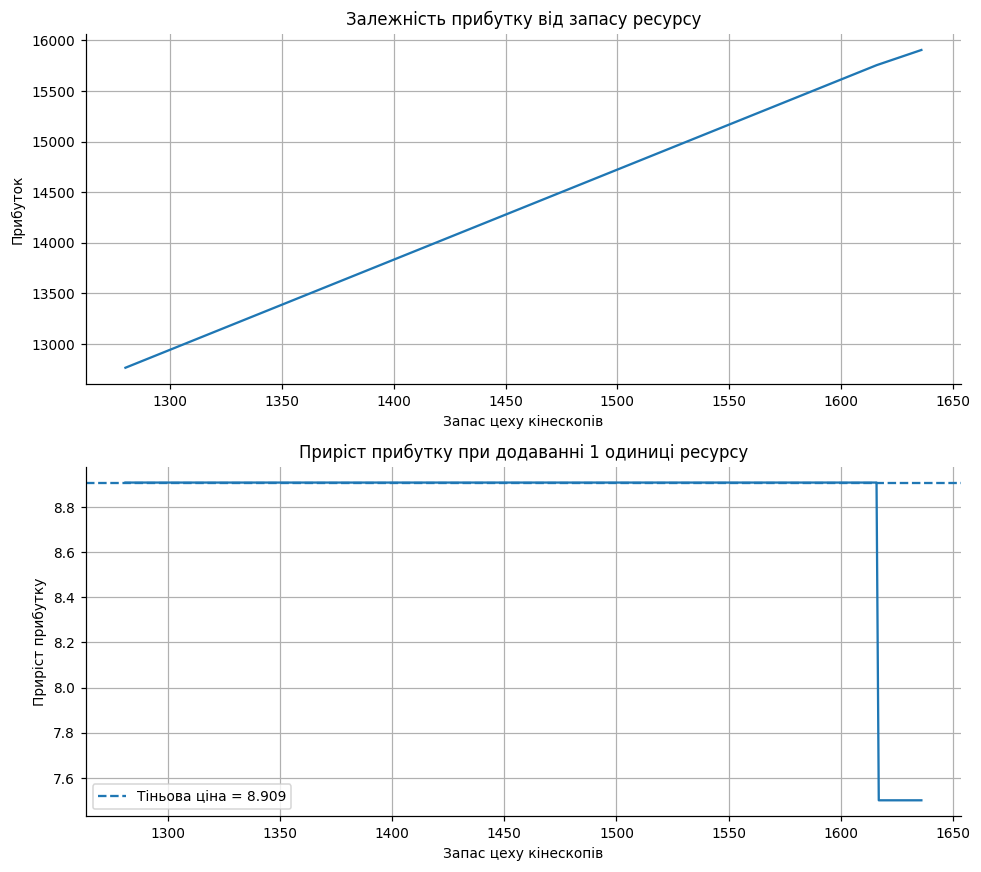

Злам починається при запасі: 1617
Збільшення від базового значення: 337


In [9]:
stocks = []
profits = []

stock = 1280
shadow_price = 8.909

break_stock = None
after_break = 0

while True:
    b_new = b.copy()
    b_new[2] = stock

    r_temp = linprog(
    -c,
    A_ub=A,
    b_ub=b_new,
    bounds=(0, None),
    method="highs"
)

    profit = -r_temp.fun


    stocks.append(stock)
    profits.append(profit)

    if len(profits) > 1:
        growth = profits[-1] - profits[-2]

        if break_stock is None and abs(growth - shadow_price) > 0.01:
            break_stock = stock

        if break_stock is not None:
            after_break += 1

            if after_break >= 20:
                break

    stock += 1


growths = np.diff(profits)

fig, ax = plt.subplots(2, 1, figsize=(9, 8))

ax[0].plot(stocks, profits)
ax[0].set_xlabel("Запас цеху кінескопів")
ax[0].set_ylabel("Прибуток")
ax[0].set_title("Залежність прибутку від запасу ресурсу")
ax[0].grid()

ax[1].plot(stocks[1:], growths)
ax[1].axhline(
    shadow_price,
    linestyle="--",
    label="Тіньова ціна = 8.909"
)

ax[1].set_xlabel("Запас цеху кінескопів")
ax[1].set_ylabel("Приріст прибутку")
ax[1].set_title("Приріст прибутку при додаванні 1 одиниці ресурсу")
ax[1].ticklabel_format(style="plain", axis="y", useOffset=False)
ax[1].grid()
ax[1].legend()

plt.tight_layout()
plt.show()

print("Злам починається при запасі:", break_stock)
print("Збільшення від базового значення:", break_stock - 1280)

**Відповідь 5.2:** *(на скільки одиниць можна збільшити запас, доки тіньова ціна не зміниться;
чи збігається знайдена межа з «допустимим збільшенням» зі звіту Excel)* Запас ресурсу можна збільшити приблизно на 337 одиниць від базового значення 1280, доки тіньова ціна залишається незмінною. Після цього значення на графіку приросту спостерігається злам, тобто тіньова ціна змінюється. Отримана межа не збігається на 1 год з допустимим збільшенням, наведеним у звіті Excel

---
# Етап 6. Рішення про закупівлю

Постачальник пропонує вам додатковий обсяг ресурсу — див. блок «ПРОПОЗИЦІЯ
ПОСТАЧАЛЬНИКА» у ваших даних.

### Завдання 6.1
Дайте відповідь директорові на три питання, спираючись на числа, а не на здоровий глузд:

1. **Брати чи не брати?** Порівняйте ціну пропозиції з тіньовою ціною.
2. **Скільки саме брати?** Постачальник пропонує більше, ніж вам потрібно.
3. **Скільки на цьому заробимо?** Порахуйте виграш і перевірте його прямим
   розв'язанням задачі з новим запасом.

In [10]:
resource_index = 2
resource = 'Цех кінескопів'
price = 6.1
offer = 672

quantities = np.arange(offer + 1)
net_gains = []
production_profits = []

for q in quantities:
    b_new = b.copy()
    b_new[resource_index] += q
    r_q = linprog(-c, A_ub=A, b_ub=b_new, bounds=(0, None), method='highs')
    p_q = -r_q.fun
    production_profits.append(p_q)
    net_gains.append(p_q - прибуток - price * q)

best_q = int(quantities[np.argmax(net_gains)])
best_net_gain = float(np.max(net_gains))
new_profit = production_profits[best_q]
direct_gain = new_profit - прибуток
purchase_cost = price * best_q

print('Ресурс:', resource)
print('Ціна постачальника:', price)
print('Початкова тіньова ціна:', 8.90909091)
print('Обсяг пропозиції:', offer)
print('Оптимально купити:', best_q)
print('Старий прибуток:', прибуток)
print('Новий виробничий прибуток:', new_profit)
print('Приріст виробничого прибутку:', direct_gain)
print('Вартість закупівлі:', purchase_cost)
print('Чистий виграш:', best_net_gain)

print('Приріст для одиниць 1..336 ≈', production_profits[1] - production_profits[0])
print('Приріст після першого зламу ≈', production_profits[337] - production_profits[336])


Ресурс: Цех кінескопів
Ціна постачальника: 6.1
Початкова тіньова ціна: 8.90909091
Обсяг пропозиції: 672
Оптимально купити: 672
Старий прибуток: 12762.545454545454
Новий виробничий прибуток: 18276.0
Приріст виробничого прибутку: 5513.454545454546
Вартість закупівлі: 4099.2
Чистий виграш: 1414.2545454545461
Приріст для одиниць 1..336 ≈ 8.909090909091901
Приріст після першого зламу ≈ 7.5


**Відповідь 6.1:**

* Брати чи ні і чому: так, ресурс варто купувати, оскільки його тіньова ціна 8.909 є більшою за ціну постачальника 6.1. Тобто додаткова одиниця ресурсу приносить більше прибутку, ніж коштує.
* Скільки одиниць має сенс купити і чому не більше: Має сенс купити всі 672 одиниці. Перші 336 одиниць оцінюються за тіньовою ціною 8.9091, а наступні — приблизно за 7.5; обидва значення перевищують ціну 6.1.
* Очікуваний виграш: иробничий прибуток зростає з 12762.5455 до 18276.0, тобто на 5513.4545. Закупівля коштує 4099.2, тому чистий виграш становить приблизно 1414.2545.
* Перевірка прямим розв'язанням дала: новий оптимальний прибуток 18276.0; після віднімання вартості 672·6.1 отримуємо чистий виграш 1414.2545, тому закупівля всього запропонованого обсягу є вигідною.



---
# Етап 7. Перевірка розв'язку

### Завдання 7.1
Порахуйте дві величини:

* скільки виробів мають **ненульовий** випуск;
* скільки обмежень **зв'язні** (ресурс витрачено повністю).

Порівняйте.

In [13]:
used = A @ план
ненульових = int(np.sum(план > 1e-8))
звязних = int(np.sum(np.isclose(used, b, atol=1e-7)))

print('План:', план)
print('Використання ресурсів:', used)
print('Запаси:', b)

План: [ 30.54545455 281.81818182   0.           0.        ]
Використання ресурсів: [ 716.36363636  152.72727273 1280.          404.          183.27272727]
Запаси: [1147 1199 1280  404 1170]


In [14]:
assert ненульових is not None and звязних is not None, 'спершу порахуйте'
print('ненульових змінних: %s | зв’язних обмежень: %s' % (ненульових, звязних))
assert ненульових == звязних, ('числа не збіглися — це сигнал. Перевірте розв’язок '
                               'і поясніть причину в клітинці нижче')
print('Етап 7 пройдено')

ненульових змінних: 2 | зв’язних обмежень: 2
Етап 7 пройдено


**Відповідь 7.1:** *(чи збіглися числа; що означала б розбіжність на практиці)* числа збіглися. Розбіжність могла б означати виродженість базисного розв'язку або бути сигналом, що активні обмеження/розв'язок пораховано неправильно.

---
# Етап 8. Цілочисельність

Ваш оптимальний план містить дробові числа. Виготовити 63,3 виробу неможливо.

### Завдання 8.1
Порівняйте три варіанти:

1. розв'язок без умови цілочисельності (уже маєте);
2. **округлений** план — округліть кожне значення до цілого й перевірте, чи він
   узагалі допустимий і скільки прибутку дає;
3. справжній **цілочисельний** оптимум — розв'яжіть задачу з умовою, що всі змінні цілі
   (`cat='Integer'` у PuLP або `integrality=1` у `linprog`).

In [15]:
continuous_plan = план.copy()
continuous_profit = прибуток

rounded_plan = np.rint(continuous_plan).astype(int)
rounded_used = A @ rounded_plan
rounded_feasible = bool(np.all(rounded_used <= b + 1e-9) and np.all(rounded_plan >= 0))
rounded_profit = float(c @ rounded_plan)

r_int = linprog(-c, A_ub=A, b_ub=b, bounds=(0, None),
                integrality=np.ones(len(c)), method='highs')
integer_plan = np.rint(r_int.x).astype(int)
integer_profit = -r_int.fun
integer_feasible = bool(np.all(A @ integer_plan <= b + 1e-9))

print('Неперервний:', continuous_plan, continuous_profit)
print('Округлений:', rounded_plan, rounded_profit, 'допустимий:', rounded_feasible)
print('Використання ресурсів округленим планом:', rounded_used)
print('Цілочисельний оптимум:', integer_plan, integer_profit, 'допустимий:', integer_feasible)


Неперервний: [ 30.54545455 281.81818182   0.           0.        ] 12762.545454545454
Округлений: [ 31 282   0   0] 12796.0 допустимий: False
Використання ресурсів округленим планом: [ 719  155 1283  406  186]
Цілочисельний оптимум: [ 30 281   1   0] 12752.999999999998 допустимий: True


**Відповідь 8.1:**

| Варіант | План                  | Прибуток  | Допустимий? |
|---|-----------------------|-----------|-------------|
| без умови цілочисельності | 30.545, 281.818, 0, 0 | 12762.545 | так         |
| округлений | 31, 282, 0, 0         | 12796     | ні          |
| цілочисельний оптимум | 30, 281, 1, 0         | 12752.99  | Так         |

**Висновок:** *(чи можна округлювати і чому)* просто округлювати неперервний оптимум не можна, тому що округлення може порушити ресурсні обмеження. У цьому випадку округлений план потребує 1283 год цеху кінескопів при запасі 1280 та 406 год цеху корпусів при запасі 404, тому він недопустимий. Для дискретного виробництва треба окремо розв’язувати цілочисельну задачу.


---
# ЧАСТИНА 2. Транспортна задача

Друга частина виконується самостійно. Тут ви застосуєте ту саму методику до задачі
іншого класу — і побачите, що вона поводиться інакше.

# Етап 9. Ваші дані

### Завдання 9.1
Сформуйте власні дані:

* **три міста-постачальники** — за першими трьома літерами вашого **прізвища**;
* **чотири міста-споживачі** — за першими чотирма літерами вашого **імені**;
* **матриця відстаней 3 × 4** — реальні відстані автошляхами за Google Maps, у кілометрах;
* **запаси і попит** — невеликі цілі числа, підберіть так, щоб **сумарний запас
  дорівнював сумарному попиту**.

> Якщо на якусь літеру міста немає — беріть наступну літеру прізвища чи імені.
> Якщо сумарний запас не дорівнює попиту, задача з обмеженнями-рівностями
> **не матиме розв'язку взагалі**. Це не помилка Python — це властивість моделі.

In [18]:
# ВАШ КОД — впишіть свої дані
постачальники = ["Львів", "Яворів", "Шептицький" ]            # напр. ['Шостка', 'Енергодар', 'Вінниця']
споживачі     = ["Луцьк", "Енергодар", "Сарни", "Яремче"]            # напр. ['Тернопіль', 'Афанасіївка', 'Рівне', 'Апостолове']
D = np.array([
            [152, 1173, 283, 195],
             [207, 1239, 343, 253],
             [108, 1239, 255, 272]], dtype=float)              # матриця відстаней 3 x 4, км
запас = [20, 30, 15]                    # 3 числа
попит = [25, 5, 10, 25]                    # 4 числа

assert len(постачальники) == 3 and len(споживачі) == 4, 'потрібно 3 постачальники і 4 споживачі'
assert D.shape == (3, 4), 'матриця відстаней має бути 3 x 4'
assert sum(запас) == sum(попит), 'сумарний запас має дорівнювати сумарному попиту'
pd.DataFrame(D, index=постачальники, columns=споживачі)

,Луцьк,Енергодар,Сарни,Яремче
Львів,152.0,1173.0,283.0,195.0
Яворів,207.0,1239.0,343.0,253.0
Шептицький,108.0,1239.0,255.0,272.0


---
# Етап 10. Розв'язання транспортної задачі

### Завдання 10.1
Розв'яжіть задачу **двічі різними засобами**: наприклад `pulp` і
`scipy.optimize.linprog(method='highs')`. Обмеження — рівності.

Для кожного розв'язку виведіть: оптимальний план перевезень, сумарну вартість
і **тіньові ціни всіх обмежень**.

In [19]:
m, n = D.shape
A_eq = []
b_eq = []

for i in range(m):
    row = np.zeros(m*n)
    row[i*n:(i+1)*n] = 1
    A_eq.append(row)
    b_eq.append(запас[i])

for j in range(n):
    row = np.zeros(m*n)
    row[j::n] = 1
    A_eq.append(row)
    b_eq.append(попит[j])

A_eq = np.array(A_eq)
b_eq = np.array(b_eq, dtype=float)

tr_scipy = linprog(D.ravel(), A_eq=A_eq, b_eq=b_eq,
                   bounds=(0, None), method='highs')
plan_scipy = tr_scipy.x.reshape(m, n)
cost_scipy = tr_scipy.fun
dual_scipy = tr_scipy.eqlin.marginals

print('План scipy:')
print(pd.DataFrame(plan_scipy, index=постачальники, columns=споживачі))
print('Вартість:', cost_scipy)
print('Тіньові ціни постачальників:', dual_scipy[:m])
print('Тіньові ціни споживачів:', dual_scipy[m:])

План scipy:
            Луцьк  Енергодар  Сарни  Яремче
Львів         0.0        5.0   10.0     5.0
Яворів       10.0        0.0    0.0    20.0
Шептицький   15.0        0.0    0.0     0.0
Вартість: 18420.0
Тіньові ціни постачальників: [ -0.  58. -41.]
Тіньові ціни споживачів: [ 149. 1173.  283.  195.]


In [20]:
import networkx as nx

G = nx.DiGraph()
for i, city in enumerate(постачальники):
    G.add_node('S'+str(i), demand=-int(запас[i]))
for j, city in enumerate(споживачі):
    G.add_node('C'+str(j), demand=int(попит[j]))
for i in range(m):
    for j in range(n):
        G.add_edge('S'+str(i), 'C'+str(j), weight=int(D[i,j]), capacity=sum(запас))

flow = nx.min_cost_flow(G)
plan_nx = np.array([[flow['S'+str(i)]['C'+str(j)] for j in range(n)] for i in range(m)], dtype=float)
cost_nx = float(np.sum(plan_nx * D))


rows = []
rhs = []
for i in range(m):
    for j in range(n):
        if plan_nx[i,j] > 1e-9:
            row = np.zeros(m+n); row[i] = 1; row[m+j] = 1
            rows.append(row); rhs.append(D[i,j])
row = np.zeros(m+n); row[0] = 1
rows.append(row); rhs.append(50.0)
potentials, *_ = np.linalg.lstsq(np.array(rows), np.array(rhs), rcond=None)
dual_nx = potentials

print('План networkx:')
print(pd.DataFrame(plan_nx, index=постачальники, columns=споживачі))
print('Вартість:', cost_nx)
print('Тіньові ціни постачальників:', dual_nx[:m])
print('Тіньові ціни споживачів:', dual_nx[m:])


План networkx:
            Луцьк  Енергодар  Сарни  Яремче
Львів         0.0        5.0   10.0     5.0
Яворів       10.0        0.0    0.0    20.0
Шептицький   15.0        0.0    0.0     0.0
Вартість: 18420.0
Тіньові ціни постачальників: [ 50. 108.   9.]
Тіньові ціни споживачів: [  99. 1123.  233.  145.]


### Завдання 10.2 — головне питання цієї частини
Порівняйте два набори тіньових цін.

**Сумарна вартість у двох розв'язувачів однакова. А тіньові ціни?**

Якщо вони різні — це не помилка. Знайдіть закономірність: подивіться на різницю
між відповідними значеннями окремо для постачальників і окремо для споживачів.

In [21]:
print('Вартість scipy:', cost_scipy)
print('Вартість networkx:', cost_nx)
print('Різниця планів:')
print(plan_scipy - plan_nx)

supplier_diff = dual_nx[:m] - dual_scipy[:m]
consumer_diff = dual_nx[m:] - dual_scipy[m:]

print('Різниця тіньових цін постачальників:', supplier_diff)
print('Різниця тіньових цін споживачів:', consumer_diff)
print('Для постачальників різниця стала:', np.allclose(supplier_diff, supplier_diff[0]))
print('Для споживачів різниця стала:', np.allclose(consumer_diff, consumer_diff[0]))


Вартість scipy: 18420.0
Вартість networkx: 18420.0
Різниця планів:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Різниця тіньових цін постачальників: [50. 50. 50.]
Різниця тіньових цін споживачів: [-50. -50. -50. -50.]
Для постачальників різниця стала: True
Для споживачів різниця стала: True


**Відповідь 10.2:**

* Вартість у двох розв'язувачів: 18420
* Тіньові ціни збіглися чи ні: ні
* Яку закономірність ви побачили в різниці: різниця скрізь 50. до всіх потенціалів постачальників можна додати одну й ту саму сталу, а від усіх потенціалів споживачів відняти цю саму сталу
* Що це означає для того, хто збирається ухвалювати рішення за цим звітом: у збалансованій транспортній задачі одна з 7 рівностей є лінійно залежною, тому абсолютні значення тіньових цін не є єдиними. Для управлінського висновку треба враховувати нормалізацію потенціалів і не порівнювати окремі абсолютні тіньові ціни з різних розв'язувачів без цього уточнення


---
# Етап 11. Перевірка розв'язку — і чому вона тут не працює

### Завдання 11.1
Порахуйте для транспортної задачі те саме, що на етапі 7:

* кількість **ненульових перевезень**;
* кількість **зв'язних обмежень**.

Порівняйте з числом `3 + 4 = 7` — кількістю обмежень у задачі.

In [22]:
ненульових_перевезень = int(np.sum(plan_scipy > 1e-8))

звязних_транспорт = m + n

print('Ненульових перевезень:', ненульових_перевезень)
print('Зв’язних обмежень:', звязних_транспорт)
print('Кількість обмежень:', m+n)
print('Незалежних рівностей:', m+n-1)


Ненульових перевезень: 6
Зв’язних обмежень: 7
Кількість обмежень: 7
Незалежних рівностей: 6


**Відповідь 11.1:**

* Ненульових перевезень: 6
* Зв'язних обмежень: 7
* Чому в транспортній задачі зв'язними виявляються **всі** обмеження: обмеження транспортної задачі задані як рівності: весь запас кожного постачальника має бути відправлений, а попит кожного споживача — повністю задоволений.
* На скільки ненульових перевезень менше і чому саме на стільки: ненульових перевезень на 1 менше, ніж зв'язних обмежень. У збалансованій транспортній задачі одна з рівностей є надлишковою, бо загальний запас дорівнює загальному попиту. Тому незалежних обмежень лише 6, що й відповідає кількості ненульових перевезень у невиродженому базисному плані


### Завдання 11.2 — візуалізація
Побудуйте дві теплові карти поруч: матрицю відстаней і матрицю оптимальних перевезень.
Підпишіть осі та значення в комірках.

*За бажанням (не оцінюється): граф маршрутів через `networkx`, де товщина ребра
пропорційна обсягу перевезення.*

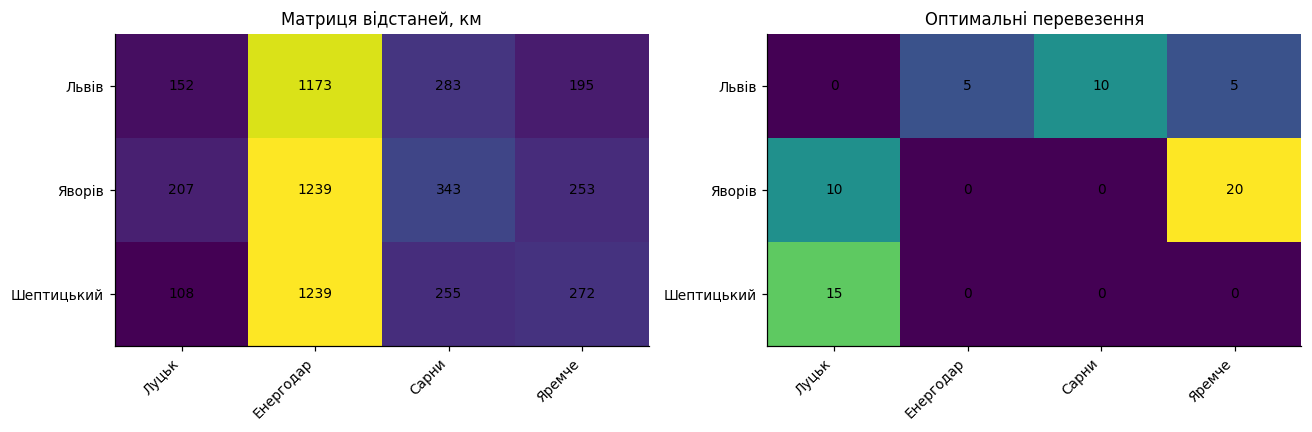

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

im1 = ax[0].imshow(D, aspect='auto')
ax[0].set_title('Матриця відстаней, км')
ax[0].set_xticks(range(n), споживачі, rotation=45, ha='right')
ax[0].set_yticks(range(m), постачальники)
for i in range(m):
    for j in range(n):
        ax[0].text(j, i, f'{D[i,j]:.0f}', ha='center', va='center')

im2 = ax[1].imshow(plan_scipy, aspect='auto')
ax[1].set_title('Оптимальні перевезення')
ax[1].set_xticks(range(n), споживачі, rotation=45, ha='right')
ax[1].set_yticks(range(m), постачальники)
for i in range(m):
    for j in range(n):
        ax[1].text(j, i, f'{plan_scipy[i,j]:.0f}', ha='center', va='center')

plt.tight_layout()
plt.show()


**Висновок:** *(одне речення про те, що видно на теплових картах)*  видно, що оптимальний план концентрує перевезення на відносно вигідних маршрутах, але через обмеження запасів і попиту частина вантажу все одно спрямовується не лише за найкоротшими відстанями

---
# Етап 12. Декларація про використання інструментів штучного інтелекту

Користуватися мовними моделями **дозволено**. Обов'язковою є прозорість.
Порушенням є не використання інструмента, а нездатність пояснити власний код
і власні числа на захисті.

Для кожного етапу оберіть одне: `'ні'`, `'синтаксис'`, `'код, перевірено'`,
`'текст, перероблено'`, `'текст, як є'`.

In [24]:
ІНСТРУМЕНТИ_ШІ = 'ChatGPT'     # напр. 'ChatGPT' або 'не використовував'

ДЕКЛАРАЦІЯ = {
    'етап 1, формалізація моделі':          'ні',
    'етап 2, побудова моделі в Excel':      'ні',
    'етап 3, код на Python':                'ні',
    'етапи 4–5, читання та перевірка звіту': 'код, перевірено',
    'етап 6, рішення про закупівлю':        'код, перевірено',
    'етапи 7–8, перевірка та цілочисельність': 'код, перевірено',
    'етапи 9–11, транспортна задача':       'код, перевірено',
}

# Що саме ви перевірили за згенерованим кодом чи текстом — конкретно.
ЩО_ПЕРЕВІРЕНО = 'було згенеровано задачі з готових бібліотек, оскільки це швидко формує задачу. також побудовано графіки за допомогою чату'

# True означає: я можу пояснити кожен рядок свого коду, відтворити будь-яке число
# цієї роботи та внести зміни в модель на вимогу під час захисту.
ПІДТВЕРДЖУЮ = True

In [25]:
# --- перевірка повноти декларації: клітинку не редагувати --------------------
ДОЗВОЛЕНІ = {'ні', 'синтаксис', 'код, перевірено', 'текст, перероблено', 'текст, як є'}
assert ІНСТРУМЕНТИ_ШІ.strip(), 'Вкажіть інструменти або напишіть «не використовував»'
порожні = [k for k, v in ДЕКЛАРАЦІЯ.items() if not str(v).strip()]
assert not порожні, 'Не заповнено: %s' % '; '.join(порожні)
чужі = {v for v in ДЕКЛАРАЦІЯ.values() if v not in ДОЗВОЛЕНІ}
assert not чужі, 'Недопустимі значення: %s' % ', '.join(sorted(чужі))
assert len(ЩО_ПЕРЕВІРЕНО.strip()) >= 120, ('Опишіть конкретніше (зараз %d символів, '
                                           'потрібно щонайменше 120)' % len(ЩО_ПЕРЕВІРЕНО.strip()))
assert ПІДТВЕРДЖУЮ is True, 'Підтвердьте, що можете пояснити власний код на захисті'
print('ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ')
print('=' * 78)
print('%-42s %s' % ('автор:', ПІБ))
print('%-42s %s' % ('інструменти:', ІНСТРУМЕНТИ_ШІ))
print('-' * 78)
for k, v in ДЕКЛАРАЦІЯ.items():
    print('%-42s %s' % (k + ':', v))
print('-' * 78)
print(ЩО_ПЕРЕВІРЕНО)

ДЕКЛАРАЦІЯ ПРО ВИКОРИСТАННЯ ІНСТРУМЕНТІВ ШІ
автор:                                     Ляшко Леся
інструменти:                               ChatGPT
------------------------------------------------------------------------------
етап 1, формалізація моделі:               ні
етап 2, побудова моделі в Excel:           ні
етап 3, код на Python:                     ні
етапи 4–5, читання та перевірка звіту:     код, перевірено
етап 6, рішення про закупівлю:             код, перевірено
етапи 7–8, перевірка та цілочисельність:   код, перевірено
етапи 9–11, транспортна задача:            код, перевірено
------------------------------------------------------------------------------
було згенеровано задачі з готових бібліотек, оскільки це швидко формує задачу. також побудовано графіки за допомогою чату


---
# Крок 13. Фінальна самоперевірка

In [26]:
перевірки = {
    'ПІБ і варіант заповнено':            bool(ПІБ) and 1 <= ВАРІАНТ <= 30,
    'Excel і Python дали однаковий план': abs(прибуток - EXCEL_ПРИБУТОК) < 0.5,
    'перевірку «ненульові = зв’язні» зроблено': ненульових == звязних,
    'дані транспортної задачі введено':   len(постачальники) == 3 and len(споживачі) == 4,
    'баланс запасів і попиту':            sum(запас) == sum(попит),
    'декларацію заповнено':               bool(ІНСТРУМЕНТИ_ШІ.strip()) and ПІДТВЕРДЖУЮ is True,
}
for k, v in перевірки.items():
    print(('OK   ' if v else 'НЕ ОК') + '  ' + k)
if all(перевірки.values()):
    print('\nТехнічна частина виконана.')
    print('Переконайтеся, що заповнені ВСІ клітинки з відповідями,')
    print('і виконайте Kernel → Restart & Run All перед здачею.')

OK     ПІБ і варіант заповнено
OK     Excel і Python дали однаковий план
OK     перевірку «ненульові = зв’язні» зроблено
OK     дані транспортної задачі введено
OK     баланс запасів і попиту
OK     декларацію заповнено

Технічна частина виконана.
Переконайтеся, що заповнені ВСІ клітинки з відповідями,
і виконайте Kernel → Restart & Run All перед здачею.
